In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\Users\amar\Downloads\ford.csv")

In [5]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


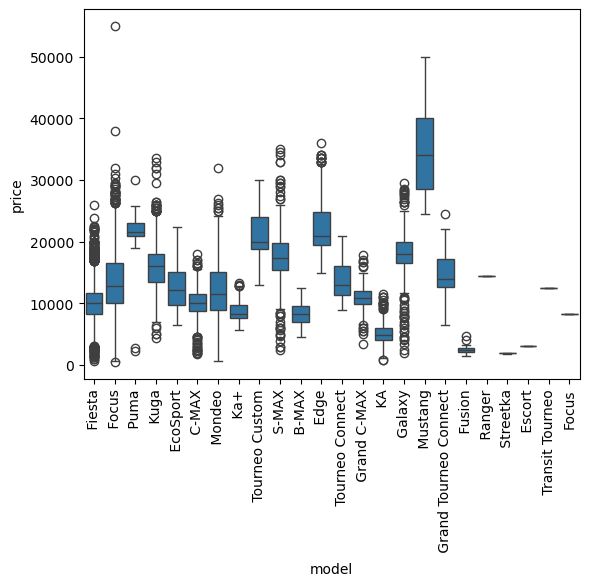

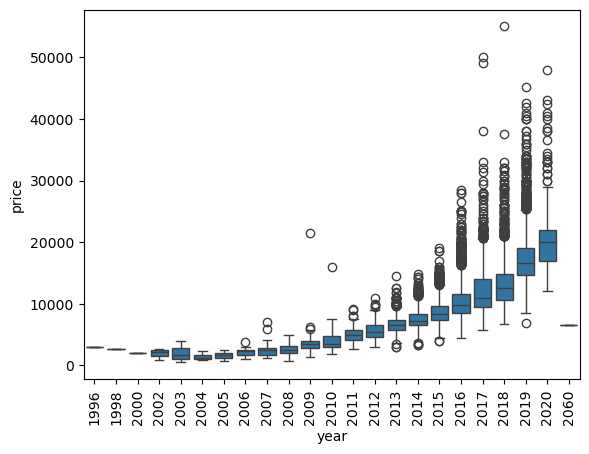

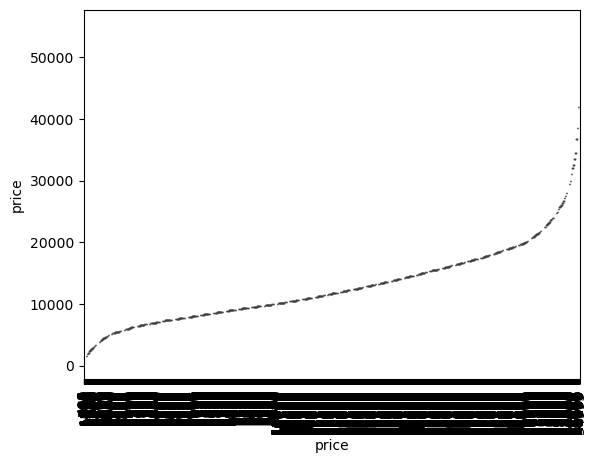

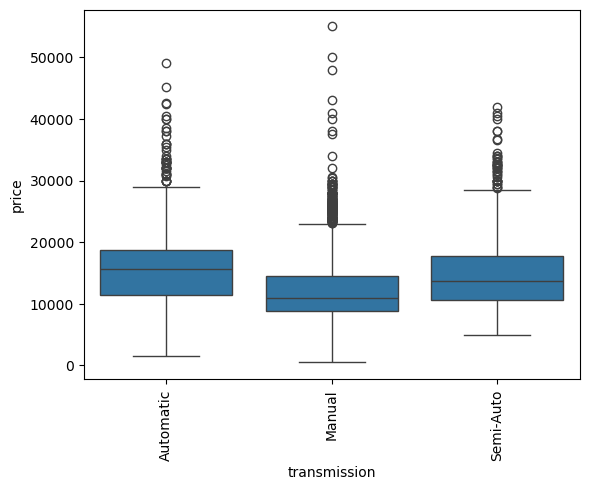

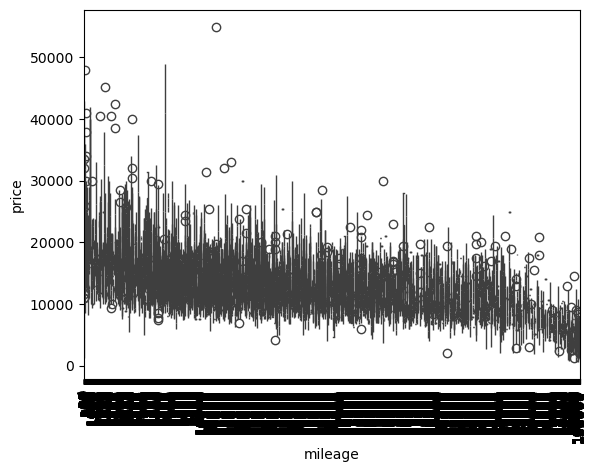

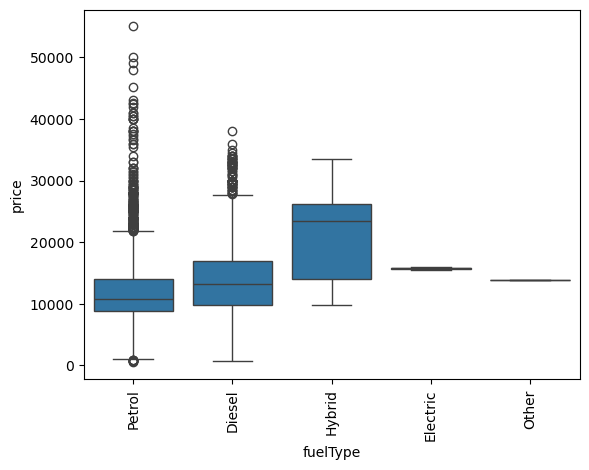

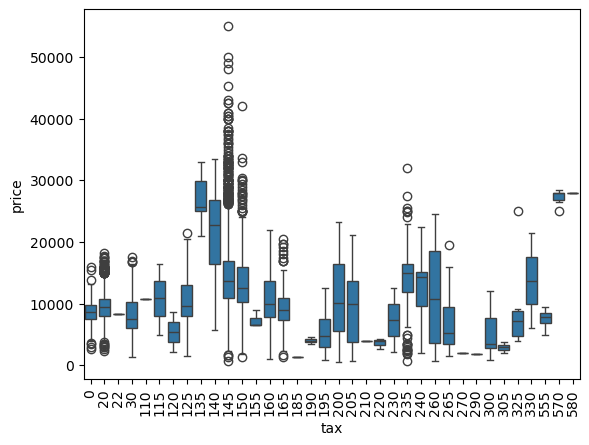

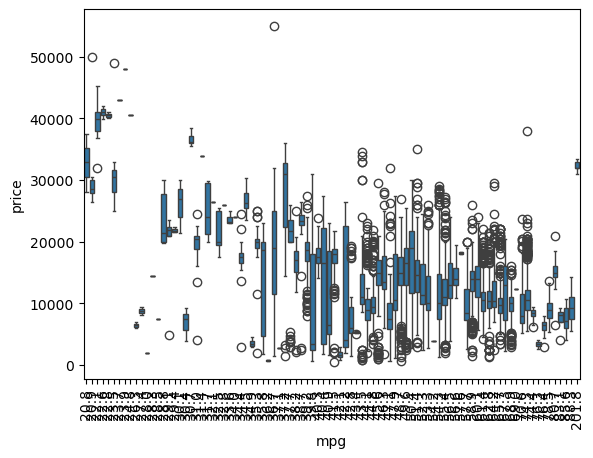

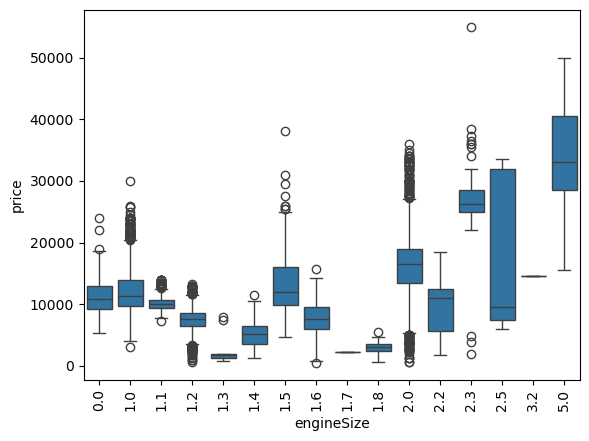

In [6]:
for i in df.columns:
    sns.boxplot(data=df, x=i, y="price")
    plt.xticks(rotation=90)
    plt.show()

In [7]:
df=pd.get_dummies(df,columns=["model","transmission","fuelType"],drop_first=True)

In [8]:
df=df.astype('int')

In [9]:
df_removed=df.drop("price",axis=1)
df_temp=df.drop("price",axis=1)

In [10]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
df_removed=scalar.fit_transform(df_removed)

In [11]:
df_removed=pd.DataFrame(df_removed,columns=df_temp.columns)

In [12]:
df_removed

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.328125,0.089747,0.258621,0.204420,0.2,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.343750,0.051125,0.258621,0.204420,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.328125,0.070113,0.258621,0.204420,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.359375,0.058877,0.250000,0.110497,0.2,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.359375,0.008337,0.250000,0.154696,0.2,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.328125,0.094003,0.258621,0.149171,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
17962,0.281250,0.229106,0.051724,0.204420,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
17963,0.296875,0.039456,0.034483,0.259669,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
17964,0.343750,0.028180,0.250000,0.204420,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
model = RandomForestRegressor()

In [14]:
X=df_removed
y=df["price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

In [15]:
pred

array([13645.16, 18070.03,  7634.62, ..., 10124.46,  9218.6 ,  7914.7 ])

In [16]:
import pandas as pd
pd.DataFrame({"actual":y_test, "predicted":pred})

,actual,predicted
9696,14990,13645.16
6365,17250,18070.03
6941,8200,7634.62
13676,9298,8710.01
3411,8220,8150.87
...,...,...
17924,11850,13321.64
2988,6650,6609.10
15958,10499,10124.46
15401,9800,9218.60


In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test,pred))
print("R2:", r2_score(y_test,pred))

MAE: 914.5140986631158
R2: 0.9147898381473701


In [17]:
import joblib
joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

In [18]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.9899468304438398
Test R2: 0.9147898381473701


In [19]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores.mean())

0.9171563414887292
